In [1]:
GLOBAL_DPI = 150
GLOBAL_FIGSIZE_BAR = (16, 4.5)
GLOBAL_FIGSIZE_RADAR = (16, 9)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import warnings

def setup_fonts():
    font_dirs = ['./fonts']
    font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)
        prop = font_manager.FontProperties(fname=font_file)
    plt.rcParams['font.family'] = 'CMU Serif'

# 1a. Feature relevance (ANOVA F-statistic)
def compute_anova_f_complexity(X: pd.DataFrame, y: pd.Series) -> dict:
    print("\tcomputing ANOVA F complexity")
    f_scores, _ = f_classif(X, y)

    # Replace inf and nan with 0
    f_scores = np.nan_to_num(f_scores, nan=0.0, posinf=0.0, neginf=0.0)

    return get_stats(f_scores)

# 1b. Feature relevance (Mutual Information)
def compute_mutual_info_complexity(X: pd.DataFrame, y: pd.Series) -> dict:
    print("\tcomputing mutual information complexity")
    mi_scores = mutual_info_classif(X, y, random_state=42)
    return get_stats(mi_scores)

# 2a. Local overlap (k-Disagreeing Neighbors)
def compute_kdn_complexity(X: pd.DataFrame, y: pd.Series, k: int = None) -> dict:
    print("\tcomputing kdn complexity")
    if k is None:
        k = int(np.sqrt(len(X)))
        k = max(2, k)  # Ensure at least 2

    nn = NearestNeighbors(n_neighbors=k+1, n_jobs=-1).fit(X)  # << parallelized
    neighbors = nn.kneighbors(X, return_distance=False)[:, 1:]  # exclude self

    kdn_scores = []
    for idx, neighbor_indices in enumerate(neighbors):
        neighbor_labels = y.iloc[neighbor_indices]
        disagreement = np.mean(neighbor_labels != y.iloc[idx])
        kdn_scores.append(disagreement)

    return get_stats(np.array(kdn_scores))

# 2b. Boundary Density (Nearest Enemy Distance)
def compute_nearest_enemy_complexity(X: pd.DataFrame, y: pd.Series, k: int = None) -> dict:
    print("\tcomputing nearest enemy complexity")
    if k is None:
        k = int(np.sqrt(len(X)))
        k = max(2, k)

    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(X)  # << parallelized

    enemy_distances = []

    for i in range(len(X)):
        distances, indices = nn.kneighbors(X.iloc[[i]], n_neighbors=k)
        neighbors_y = y.iloc[indices[0]]
        neighbors_distances = distances[0]

        for dist, label in zip(neighbors_distances[1:], neighbors_y[1:]):  # skip self
            if label != y.iloc[i]:
                enemy_distances.append(dist)
                break

    return get_stats(np.array(enemy_distances))

# 3. Margin-based hardness (Approximate Margin)
def compute_margin_complexity(X: pd.DataFrame, y: pd.Series) -> dict:
    print("\tcomputing margin complexity")
    # Use a linear SVM to approximate margins
    clf = SVC(kernel='linear', probability=False, random_state=42)
    clf.fit(X, y)
    decision_function = clf.decision_function(X)

    if len(decision_function.shape) == 1:  # binary case
        margins = np.abs(decision_function)
    else:  # multiclass case
        margins = np.min(decision_function, axis=1)

    return get_stats(margins)

def compute_margin_complexity_fast(X: pd.DataFrame, y: pd.Series) -> dict:
    print("\tcomputing margin complexity (LinearSVC version)")
    clf = LinearSVC(dual=False, random_state=42, max_iter=20000)
    clf.fit(X, y)

    # Calculate margin = distance to the decision boundary
    decision_function = clf.decision_function(X)

    if len(decision_function.shape) == 1:  # binary
        margins = np.abs(decision_function)
    else:  # multiclass (one-vs-rest margins)
        margins = np.min(decision_function, axis=1)

    return get_stats(margins)

# 4. Intrinsic Dimensionality (PCA variance ratio)
def compute_intrinsic_dimensionality(X: pd.DataFrame, threshold: float = 0.95) -> dict:
    print("\tcomputing intrinsic dimensionality")
    pca = PCA()
    pca.fit(X)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.searchsorted(cumulative_variance, threshold) + 1
    n_features = X.shape[1]

    intrinsic_dim_percent = n_components / n_features

    return {
        "n_components_95%": n_components,
        "intrinsic_dimensionality_percent": intrinsic_dim_percent  # << NEW
    }

# 5. Class Imbalance
def compute_class_imbalance(y: pd.Series) -> dict:
    print("\tcomputing class imbalance")
    class_counts = y.value_counts()
    n_classes = len(class_counts)
    max_count = class_counts.max()
    min_count = class_counts.min()

    imbalance_ratio = max_count / min_count

    # Normalized entropy
    probs = class_counts / class_counts.sum()
    entropy = -np.sum(probs * np.log(probs))
    normalized_entropy = entropy / np.log(n_classes) if n_classes > 1 else 1.0

    return {
        "n_classes": n_classes,
        "imbalance_ratio": imbalance_ratio,
        "normalized_entropy": normalized_entropy
    }

# 6. KNN Overlap Fraction
def compute_knn_overlap(X: pd.DataFrame, y: pd.Series, k: int = None) -> dict:
    print("\tcomputing KNN overlap")
    if k is None:
        k = int(np.sqrt(len(X)))
        k = max(2, k)

    clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    
    accuracy = np.mean(y_pred == y)
    overlap_fraction = 1 - accuracy

    return {"knn_overlap_fraction": overlap_fraction}

# 7. Class Centroid Distance
def compute_class_centroid_distance(X: pd.DataFrame, y: pd.Series) -> dict:
    print("\tcomputing class centroid distance")
    class_centroids = X.groupby(y).mean()
    dists = cdist(class_centroids, class_centroids)
    upper_triangle = dists[np.triu_indices_from(dists, k=1)]  # Take distances above diagonal
    mean_distance = np.mean(upper_triangle)
    return {"class_centroid_mean_distance": mean_distance}

# 8. Global Clusterability (Silhouette Score)
def compute_clusterability(X: pd.DataFrame, y: pd.Series) -> dict:
    print("\tcomputing clusterability (silhouette score)")
    try:
        # Use true labels for silhouette (clusters = classes)
        score = silhouette_score(X, y)
    except Exception:
        # If silhouette computation fails (e.g., only one class), set to NaN
        score = np.nan
    return {"silhouette_score": score}

# Helper: get basic statistics
def get_stats(values: np.ndarray) -> dict:
    return {
        "size": len(values),
        "max": np.max(values),
        "min": np.min(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "Q1": np.percentile(values, 25),
        "Q3": np.percentile(values, 75),
        "Q3-Q1": np.percentile(values, 75) - np.percentile(values, 25),
        "stdev": np.std(values),
        "variance": np.var(values)
    }

# Master function to compute all complexity measures
def compute_all_complexity_measures(X: pd.DataFrame, y: pd.Series) -> dict:
    results = {}
    results['anova_f'] = compute_anova_f_complexity(X, y)
    results['mutual_info'] = compute_mutual_info_complexity(X, y)
    results['kdn'] = compute_kdn_complexity(X, y)
    results['nearest_enemy'] = compute_nearest_enemy_complexity(X, y)
    results['margin'] = compute_margin_complexity_fast(X, y)
    results['intrinsic_dimensionality'] = compute_intrinsic_dimensionality(X)
    results['class_imbalance'] = compute_class_imbalance(y)
    results['knn_overlap'] = compute_knn_overlap(X, y)
    results['centroid_distance'] = compute_class_centroid_distance(X, y)
    results['clusterability'] = compute_clusterability(X, y)
    return results

In [3]:
setup_fonts()

In [4]:
import pandas as pd
import json
import os
import numpy as np

# Smart fillna function
def smart_fillna(X: pd.DataFrame) -> pd.DataFrame:
    X_filled = X.copy()
    for col in X_filled.columns:
        if X_filled[col].dtype.kind in "bifc":  # Numerical types
            X_filled[col] = X_filled[col].fillna(X_filled[col].mean())
        else:  # Categorical types
            if not X_filled[col].mode().empty:
                X_filled[col] = X_filled[col].fillna(X_filled[col].mode().iloc[0])
            else:
                X_filled[col] = X_filled[col].fillna("missing")
    return X_filled

# Safe conversion for JSON serialization
def make_json_safe(obj):
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# Dataset list
datasets = [
    # Binary
    "31", "37", "44", "1462", "1479", "1510", "40945",
    # Multiclass
    "23", "36", "54", "181", "1466", "40691", "40975",
    # Multilabel
    "285", "41464", "41465", "41468", "41470", "41471", "41473"
]

ignore_cache = False
cache_file = "artifacts/complexity_metrics/complexity_metrics.json"

# Load existing cache if available
if os.path.exists(cache_file) and not ignore_cache:
    print(f"Loading existing cache from {cache_file}...")
    with open(cache_file, "r") as f:
        cached_results = json.load(f)
else:
    print("No existing cache found.")
    cached_results = {}

# Identify datasets to process
already_processed = set(cached_results.keys())
to_process = [ds for ds in datasets if ds not in already_processed]

print(f"Datasets already cached: {len(already_processed)}")
print(f"Datasets to process now: {len(to_process)}")

# Only process datasets not yet cached
for ds in to_process:
    print(f"Processing {ds}...")

    # Load and sample
    data = pd.read_csv(f"./artifacts/autobalancer_datasets/openml_{ds}.csv")
    X = data.drop(columns=["class"])
    y = data["class"]

    # Smart imputation
    X = smart_fillna(X)

    # Drop samples where label is missing
    mask_valid = y.notna()
    X = X.loc[mask_valid]
    y = y.loc[mask_valid]

    # Compute complexity measures
    complexity_measures = compute_all_complexity_measures(X, y)

    # Flatten and store
    flat_record = {}
    for measure_name, stats_dict in complexity_measures.items():
        if isinstance(stats_dict, dict):
            for stat_name, value in stats_dict.items():
                col_name = f"{measure_name}_{stat_name}"
                flat_record[col_name] = make_json_safe(value)
        else:
            flat_record[measure_name] = make_json_safe(stats_dict)

    cached_results[ds] = flat_record

# Save updated cache
print(f"Saving updated cache to {cache_file}...")
with open(cache_file, "w") as f:
    json.dump(cached_results, f, indent=2)

# Optional: Load as DataFrame
df_complexity = pd.DataFrame.from_dict(cached_results, orient="index")
df_complexity.index.name = "dataset"

display(df_complexity)

Loading existing cache from artifacts/complexity_metrics/complexity_metrics.json...
Datasets already cached: 21
Datasets to process now: 0
Saving updated cache to artifacts/complexity_metrics/complexity_metrics.json...


,anova_f_size,anova_f_max,anova_f_min,anova_f_mean,anova_f_median,anova_f_Q1,anova_f_Q3,anova_f_Q3-Q1,anova_f_stdev,anova_f_variance,...,margin_stdev,margin_variance,intrinsic_dimensionality_n_components_95%,intrinsic_dimensionality_intrinsic_dimensionality_percent,class_imbalance_n_classes,class_imbalance_imbalance_ratio,class_imbalance_normalized_entropy,knn_overlap_knn_overlap_fraction,centroid_distance_class_centroid_mean_distance,clusterability_silhouette_score
dataset,,,,,,,,,,,,,,,,,,,,,
31,20,111.721482,0.008787,15.807477,6.014296,1.198643,12.210149,11.011506,26.778980,7.171138e+02,...,0.328316,0.107791,1,0.050000,2,2.333333,0.881291,0.287000,952.689487,0.115630
37,8,213.161752,3.256950,51.932300,31.770764,11.036926,52.548476,41.511551,64.702683,4.186437e+03,...,0.361157,0.130435,2,0.250000,2,1.865672,0.933134,0.222656,45.243108,0.104260
44,57,791.726012,0.275584,164.150403,92.490564,44.024499,260.549947,216.525449,164.018596,2.690210e+04,...,7.265183,52.782891,2,0.035088,2,1.537783,0.967360,0.237992,321.024108,0.197483
1462,4,1516.626670,0.752089,472.297356,185.905332,25.777662,632.425027,606.647365,617.069142,3.807743e+05,...,2.870597,8.240324,3,0.750000,2,1.249180,0.991128,0.007289,6.825190,0.183604
1479,100,1.582808,0.245221,1.053678,1.156285,0.859804,1.341975,0.482170,0.363245,1.319466e-01,...,167.003820,27890.275898,1,0.010000,2,1.000000,1.000000,0.415842,10626.280360,0.001014
1510,30,964.385393,0.024117,315.282307,196.624245,67.214831,563.243841,496.029010,309.295072,9.566344e+04,...,3.123539,9.756498,1,0.033333,2,1.683962,0.952635,0.070299,1009.162787,0.513697
40945,13,1910.212644,0.000000,229.338234,70.179950,3.301879,123.490499,120.188620,502.620620,2.526275e+05,...,0.877099,0.769303,2,0.153846,2,1.618000,0.959422,0.268144,283.844326,0.074605
23,9,56.919377,2.597444,19.775982,15.805868,10.949670,18.090034,7.140364,15.232628,2.320330e+02,...,0.206159,0.042502,2,0.222222,3,1.888889,0.971023,0.418873,3.008668,-0.052906
36,19,5993.300259,0.000000,1750.602144,1079.892040,28.925371,4083.042086,4054.116716,1985.050223,3.940424e+06,...,12.607321,158.944536,4,0.210526,7,1.000000,1.000000,0.119913,142.659932,0.143694


In [5]:
# Save updated cache
def convert(o):
    if isinstance(o, (np.integer, np.int64)):
        return int(o)
    if isinstance(o, (np.floating, np.float64)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)  # fallback

print(f"Saving updated cache to {cache_file}...")
with open(cache_file, "w") as f:
    json.dump(cached_results, f, indent=2, default=convert)

# Load as DataFrame
df_complexity = pd.DataFrame.from_dict(cached_results, orient="index")
df_complexity.index.name = "dataset"

# Display
display(df_complexity)

Saving updated cache to artifacts/complexity_metrics/complexity_metrics.json...


,anova_f_size,anova_f_max,anova_f_min,anova_f_mean,anova_f_median,anova_f_Q1,anova_f_Q3,anova_f_Q3-Q1,anova_f_stdev,anova_f_variance,...,margin_stdev,margin_variance,intrinsic_dimensionality_n_components_95%,intrinsic_dimensionality_intrinsic_dimensionality_percent,class_imbalance_n_classes,class_imbalance_imbalance_ratio,class_imbalance_normalized_entropy,knn_overlap_knn_overlap_fraction,centroid_distance_class_centroid_mean_distance,clusterability_silhouette_score
dataset,,,,,,,,,,,,,,,,,,,,,
31,20,111.721482,0.008787,15.807477,6.014296,1.198643,12.210149,11.011506,26.778980,7.171138e+02,...,0.328316,0.107791,1,0.050000,2,2.333333,0.881291,0.287000,952.689487,0.115630
37,8,213.161752,3.256950,51.932300,31.770764,11.036926,52.548476,41.511551,64.702683,4.186437e+03,...,0.361157,0.130435,2,0.250000,2,1.865672,0.933134,0.222656,45.243108,0.104260
44,57,791.726012,0.275584,164.150403,92.490564,44.024499,260.549947,216.525449,164.018596,2.690210e+04,...,7.265183,52.782891,2,0.035088,2,1.537783,0.967360,0.237992,321.024108,0.197483
1462,4,1516.626670,0.752089,472.297356,185.905332,25.777662,632.425027,606.647365,617.069142,3.807743e+05,...,2.870597,8.240324,3,0.750000,2,1.249180,0.991128,0.007289,6.825190,0.183604
1479,100,1.582808,0.245221,1.053678,1.156285,0.859804,1.341975,0.482170,0.363245,1.319466e-01,...,167.003820,27890.275898,1,0.010000,2,1.000000,1.000000,0.415842,10626.280360,0.001014
1510,30,964.385393,0.024117,315.282307,196.624245,67.214831,563.243841,496.029010,309.295072,9.566344e+04,...,3.123539,9.756498,1,0.033333,2,1.683962,0.952635,0.070299,1009.162787,0.513697
40945,13,1910.212644,0.000000,229.338234,70.179950,3.301879,123.490499,120.188620,502.620620,2.526275e+05,...,0.877099,0.769303,2,0.153846,2,1.618000,0.959422,0.268144,283.844326,0.074605
23,9,56.919377,2.597444,19.775982,15.805868,10.949670,18.090034,7.140364,15.232628,2.320330e+02,...,0.206159,0.042502,2,0.222222,3,1.888889,0.971023,0.418873,3.008668,-0.052906
36,19,5993.300259,0.000000,1750.602144,1079.892040,28.925371,4083.042086,4054.116716,1985.050223,3.940424e+06,...,12.607321,158.944536,4,0.210526,7,1.000000,1.000000,0.119913,142.659932,0.143694


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Corrected metric groups
metric_groups = {
    "Feature_Relevance": ["anova_f_mean", "mutual_info_mean"],
    "Local_Overlap": ["kdn_mean", "knn_overlap_knn_overlap_fraction"],
    "Boundary_Hardness": ["margin_mean", "nearest_enemy_mean"],
    "Global_Structure": ["intrinsic_dimensionality_intrinsic_dimensionality_percent", "clusterability_silhouette_score"],
    "Class_Distribution_Separation": ["centroid_distance_class_centroid_mean_distance", "class_imbalance_normalized_entropy"]
}

# Corrected flip list
metrics_to_invert = [
    "anova_f_mean",
    "mutual_info_mean",
    "margin_mean",
    "nearest_enemy_mean",
    "clusterability_silhouette_score",
    "class_imbalance_normalized_entropy"
]

def compute_composite_difficulty(df_metrics: pd.DataFrame) -> pd.DataFrame:
    df = df_metrics.copy()

    # Step 1: Flip necessary metrics
    for metric in metrics_to_invert:
        if metric in df.columns:
            df[metric] = -df[metric]

    # Step 2: Normalize
    scaler = MinMaxScaler()
    flatten_metrics = [metric for metrics in metric_groups.values() for metric in metrics]
    df[flatten_metrics] = scaler.fit_transform(df[flatten_metrics])

    # Step 3: Group difficulty
    for group_name, metric_list in metric_groups.items():
        df[group_name + "_difficulty"] = df[metric_list].mean(axis=1)

    # Step 4: Overall difficulty
    group_difficulty_cols = [g + "_difficulty" for g in metric_groups.keys()]
    df["overall_difficulty"] = df[group_difficulty_cols].mean(axis=1)

    return df

In [7]:
df_complexity_final = compute_composite_difficulty(df_complexity)

display(df_complexity_final)

,anova_f_size,anova_f_max,anova_f_min,anova_f_mean,anova_f_median,anova_f_Q1,anova_f_Q3,anova_f_Q3-Q1,anova_f_stdev,anova_f_variance,...,class_imbalance_normalized_entropy,knn_overlap_knn_overlap_fraction,centroid_distance_class_centroid_mean_distance,clusterability_silhouette_score,Feature_Relevance_difficulty,Local_Overlap_difficulty,Boundary_Hardness_difficulty,Global_Structure_difficulty,Class_Distribution_Separation_difficulty,overall_difficulty
dataset,,,,,,,,,,,,,,,,,,,,,
31,20,111.721482,0.008787,0.991567,6.014296,1.198643,12.210149,11.011506,26.778980,7.171138e+02,...,2.961409e-01,0.340030,0.088493,0.329072,0.992400,0.375516,0.578320,0.187702,0.192317,0.465251
37,8,213.161752,3.256950,0.970919,31.770764,11.036926,52.548476,41.511551,64.702683,4.186437e+03,...,1.668083e-01,0.261811,0.004169,0.338472,0.958952,0.305542,0.579110,0.292788,0.085489,0.444376
44,57,791.726012,0.275584,0.906778,92.490564,44.024499,260.549947,216.525449,164.018596,2.690210e+04,...,8.142568e-02,0.280453,0.029796,0.261407,0.911701,0.307526,0.574834,0.146384,0.055611,0.399211
1462,4,1516.626670,0.752089,0.730648,185.905332,25.777662,632.425027,606.647365,617.069142,3.807743e+05,...,2.213246e-02,0.000000,0.000599,0.272880,0.735702,0.000000,0.573002,0.510957,0.011366,0.366205
1479,100,1.582808,0.245221,1.000000,1.156285,0.859804,1.341975,0.482170,0.363245,1.319466e-01,...,0.000000e+00,0.496656,0.987412,0.423823,1.000000,0.500612,0.000000,0.215000,0.493706,0.441864
1510,30,964.385393,0.024117,0.820394,196.624245,67.214831,563.243841,496.029010,309.295072,9.566344e+04,...,1.181601e-01,0.076598,0.093741,0.000000,0.761174,0.081691,0.574447,0.014801,0.105951,0.307613
40945,13,1910.212644,0.000000,0.869518,70.179950,3.301879,123.490499,120.188620,502.620620,2.526275e+05,...,1.012286e-01,0.317107,0.026341,0.362987,0.863997,0.354242,0.577078,0.256783,0.063785,0.423177
23,9,56.919377,2.597444,0.989299,15.805868,10.949670,18.090034,7.140364,15.232628,2.320330e+02,...,7.228899e-02,0.500341,0.000244,0.468397,0.980625,0.542788,0.582057,0.343808,0.036267,0.497109
36,19,5993.300259,0.000000,0.000000,1079.892040,28.925371,4083.042086,4054.116716,1985.050223,3.940424e+06,...,4.440892e-16,0.136912,0.013221,0.305873,0.000000,0.180935,0.594192,0.256676,0.006611,0.207683


In [8]:
# Key columns needed for composite difficulty
selected_columns = [
    'anova_f_mean',
    'mutual_info_mean',
    'kdn_mean',
    'knn_overlap_knn_overlap_fraction',
    'margin_mean',
    'nearest_enemy_mean',
    'intrinsic_dimensionality_n_components_95%',
    'clusterability_silhouette_score',
    'centroid_distance_class_centroid_mean_distance',
    'class_imbalance_normalized_entropy',
    'overall_difficulty'
]

# Create a clean working copy
df_complexity_small = df_complexity_final[selected_columns].copy()

display(df_complexity_small)

,anova_f_mean,mutual_info_mean,kdn_mean,knn_overlap_knn_overlap_fraction,margin_mean,nearest_enemy_mean,intrinsic_dimensionality_n_components_95%,clusterability_silhouette_score,centroid_distance_class_centroid_mean_distance,class_imbalance_normalized_entropy,overall_difficulty
dataset,,,,,,,,,,,
31,0.991567,0.993233,0.411003,0.340030,0.161008,0.995633,1,0.329072,0.088493,2.961409e-01,0.465251
37,0.970919,0.946984,0.349273,0.261811,0.160839,0.997381,2,0.338472,0.004169,1.668083e-01,0.444376
44,0.906778,0.916625,0.334599,0.280453,0.153214,0.996453,2,0.261407,0.029796,8.142568e-02,0.399211
1462,0.730648,0.740755,0.000000,0.000000,0.146331,0.999674,3,0.272880,0.000599,2.213246e-02,0.366205
1479,1.000000,1.000000,0.504568,0.496656,0.000000,0.000000,1,0.423823,0.987412,0.000000e+00,0.441864
1510,0.820394,0.701953,0.086785,0.076598,0.154681,0.994213,1,0.000000,0.093741,1.181601e-01,0.307613
40945,0.869518,0.858475,0.391377,0.317107,0.158677,0.995479,2,0.362987,0.026341,1.012286e-01,0.423177
23,0.989299,0.971950,0.585236,0.500341,0.164299,0.999814,2,0.468397,0.000244,7.228899e-02,0.497109
36,0.000000,0.000000,0.224958,0.136912,0.192848,0.995536,4,0.305873,0.013221,4.440892e-16,0.207683


In [9]:
display(df_complexity_small["overall_difficulty"])

dataset
31       0.465251
37       0.444376
44       0.399211
1462     0.366205
1479     0.441864
1510     0.307613
40945    0.423177
23       0.497109
36       0.207683
54       0.433601
181      0.589807
1466     0.528953
40691    0.578794
40975    0.581478
285      0.643359
41464    0.788801
41465    0.606636
41468    0.584838
41470    0.614145
41471    0.540171
41473    0.677160
Name: overall_difficulty, dtype: float64

In [10]:
# Binary datasets
binary_datasets = [
    "31",    # credit-g
    "37",    # diabetes
    "44",    # spambase
    "1462",  # bank-note-authentication
    "1479",  # hill-valley
    "1510",  # wdbc
    "40945"  # titanic
]

# Multiclass datasets
multiclass_datasets = [
    "23",    # contraceptive-method-choice
    "36",    # segment
    "54",    # vehicle
    "181",   # yeast (single-label)
    "1466",  # cardiotocography
    "40691", # wine-quality-red
    "40975"  # car
]

# Multilabel datasets (powerset format)
multilabel_datasets = [
    "285",   # flags
    "41464", # birds
    "41465", # emotions
    "41468", # image
    "41470", # reuters
    "41471", # scene
    "41473"  # yeast (multi-label)
]

In [11]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import numbers
from openpyxl.utils import get_column_letter

def export_complexity_to_excel(df_complexity, filename="artifacts/complexity_metrics/complexity_metrics.xlsx"):
    # Create mapping from dataset name to problem type
    problem_type_mapping = {}
    for ds in binary_datasets:
        problem_type_mapping[ds] = "Binary"
    for ds in multiclass_datasets:
        problem_type_mapping[ds] = "Multiclass"
    for ds in multilabel_datasets:
        problem_type_mapping[ds] = "Multilabel"

    # Reset index if necessary
    if df_complexity.index.name == "dataset":
        df_complexity = df_complexity.reset_index()

    # Add problem type
    df_complexity["problem_type"] = df_complexity["dataset"].map(problem_type_mapping)

    # Reorder columns: problem_type first, then dataset, then the rest
    cols = ["problem_type", "dataset"] + [col for col in df_complexity.columns if col not in ["problem_type", "dataset"]]
    df_complexity = df_complexity[cols]

    # Round numeric columns to 3 decimals
    df_complexity = df_complexity.round(3)

    # Export to Excel
    df_complexity.to_excel(filename, index=False)

    # Now fix Excel number formats
    wb = load_workbook(filename)
    ws = wb.active

    numeric_cols = df_complexity.columns[2:]  # Assuming first two columns are problem_type, dataset
    colname_to_letter = {name: get_column_letter(idx + 1) for idx, name in enumerate(df_complexity.columns)}

    for col in numeric_cols:
        col_letter = colname_to_letter[col]
        for row in range(2, ws.max_row + 1):  # Skip header
            cell = ws[f"{col_letter}{row}"]
            if isinstance(cell.value, (int, float)):
                cell.number_format = '0.000'  # Force 3 decimal places

    # Save updated Excel
    wb.save(filename)

    print(f"Successfully exported {filename} with clean 3-decimal formatting.")

In [12]:
export_complexity_to_excel(df_complexity_small)

Successfully exported artifacts/complexity_metrics/complexity_metrics.xlsx with clean 3-decimal formatting.


In [13]:
custom_palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

def plot_difficulty_groups_with_overall_subset(df_complexity_final, dataset_subset, title_suffix="", filename_suffix="", figsize=GLOBAL_FIGSIZE_BAR, ncoldiv=1):
    # Select only the subset
    df_subset = df_complexity_final.loc[dataset_subset]

    # Select group difficulty columns
    group_cols = [col for col in df_subset.columns if col.endswith("_difficulty") and col != "overall_difficulty"]

    # Reshape for seaborn
    df_plot = df_subset[group_cols].copy()
    df_plot["dataset"] = df_plot.index
    df_plot_long = df_plot.melt(id_vars="dataset", var_name="Difficulty Group", value_name="Difficulty Score")
    df_plot_long["Difficulty Group"] = df_plot_long["Difficulty Group"].str.replace("_difficulty", "").str.replace("_", " ").str.title()

    # Keep subset order
    ordered_datasets = df_subset.index.tolist()

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df_plot_long,
        x="dataset",
        y="Difficulty Score",
        hue="Difficulty Group",
        order=ordered_datasets,
        palette=custom_palette
    )

    # Overlay overall difficulty
    overall = df_subset.loc[ordered_datasets, "overall_difficulty"].values
    ax.plot(range(len(ordered_datasets)), overall, color="black", marker="o", markersize=6, linewidth=2, label="Overall Difficulty")

    # Titles, labels
    # plt.title(f"Dataset Difficulty by Group {title_suffix}", fontsize=18)
    plt.xlabel("Dataset", fontsize=16)
    plt.ylabel("Normalized Difficulty Score", fontsize=16)
    plt.xticks(rotation=0, ha="center", fontsize=12)
    plt.yticks(fontsize=12)

    handles, labels = ax.get_legend_handles_labels()
    plt.legend(
        handles=handles,
        labels=labels,
        title="Complexity Group",
        fontsize=14,
        title_fontsize=16,
        loc="lower center",        # << change location
        bbox_to_anchor=(0.5, 1.0), # << center above plot
        ncol=(len(handles) // ncoldiv),
        columnspacing=0.8,
    )

    plt.tight_layout()
    plt.savefig(f"artifacts/complexity_metrics/complexity_bars_{filename_suffix}.pdf", dpi=GLOBAL_DPI)
    plt.show()

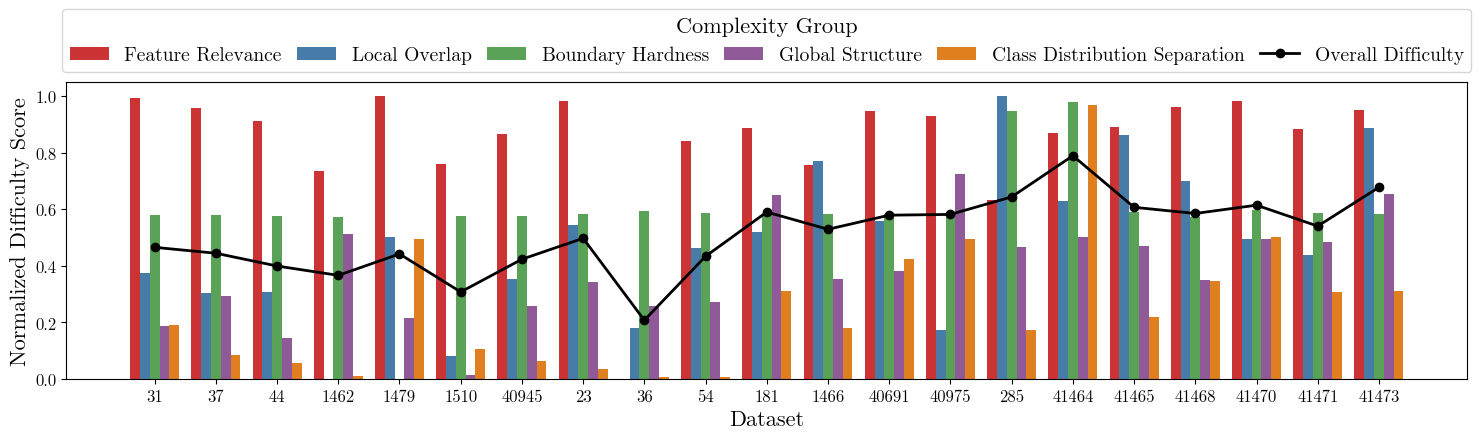

In [14]:
plot_difficulty_groups_with_overall_subset(df_complexity_final, df_complexity_final.index.tolist(), title_suffix="(All Datasets)", filename_suffix="all", figsize=GLOBAL_FIGSIZE_BAR, ncoldiv=1)

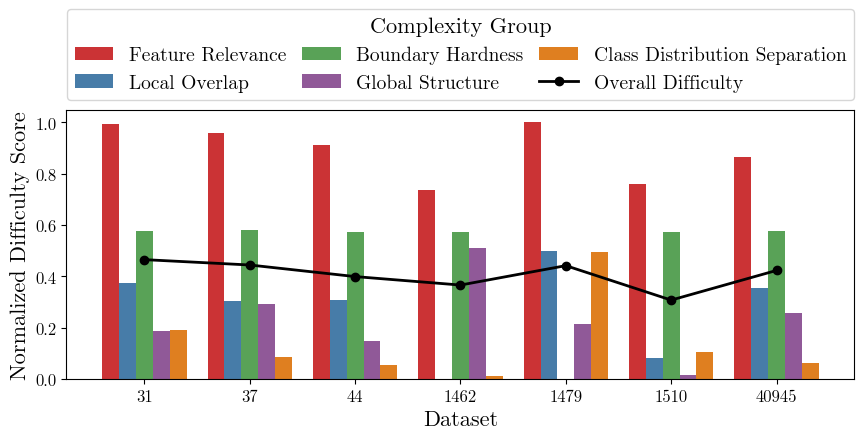

In [15]:
plot_difficulty_groups_with_overall_subset(df_complexity_final, binary_datasets, title_suffix="(Binary Classification)", filename_suffix="binary", figsize=(9.14, 4.5), ncoldiv=2)

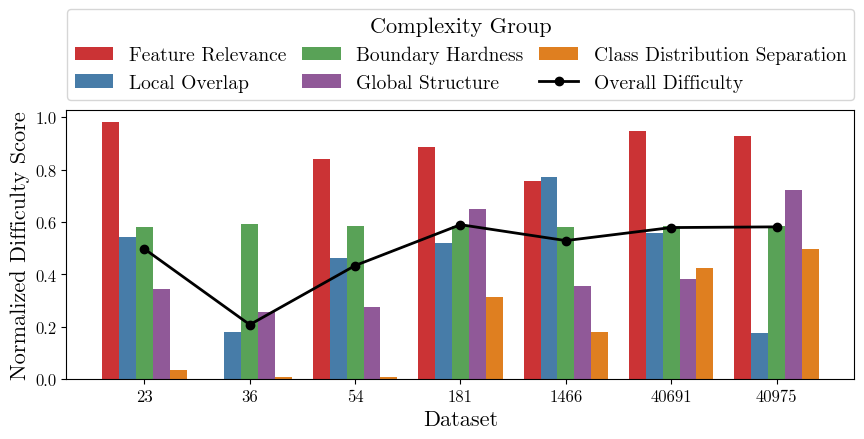

In [16]:
plot_difficulty_groups_with_overall_subset(df_complexity_final, multiclass_datasets, title_suffix="(Multiclass Classification)", filename_suffix="multiclass", figsize=(9.14, 4.5), ncoldiv=2)

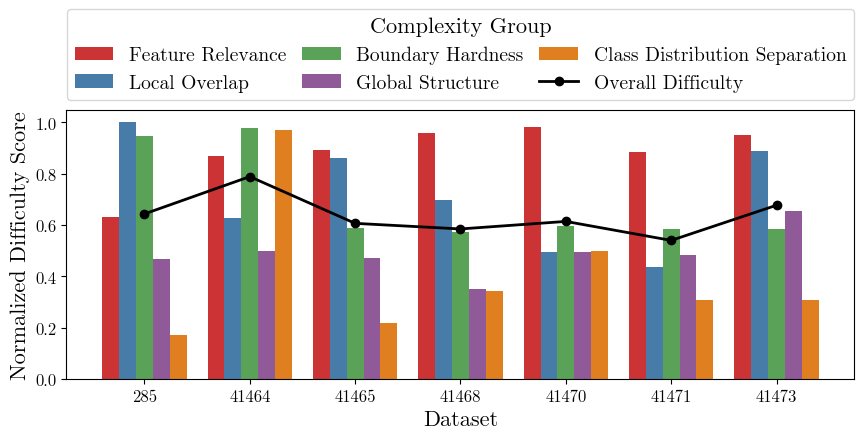

In [17]:
plot_difficulty_groups_with_overall_subset(df_complexity_final, multilabel_datasets, title_suffix="(Multilabel Classification)", filename_suffix="multilabel", figsize=(9.14, 4.5), ncoldiv=2)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_global_radar_difficulty_subset(df_complexity_final, dataset_subset, title_suffix="", filename_suffix=""):
    # Columns corresponding to the 5 group difficulty scores
    group_cols = [col for col in df_complexity_final.columns if col.endswith("_difficulty") and col != "overall_difficulty"]

    # Clean up group names for prettier display
    labels = [col.replace("_difficulty", "").replace("_", " ").title() for col in group_cols]
    labels = [x.replace(' ', '\n') if 'Feature' not in x else x for x in labels]

    # Prepare radar chart
    num_vars = len(labels)

    # Compute angle of each axis in the plot
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    fig, ax = plt.subplots(figsize=GLOBAL_FIGSIZE_RADAR, subplot_kw=dict(polar=True))

    # Plot each dataset in the subset
    for dataset_name in dataset_subset:
        if dataset_name not in df_complexity_final.index:
            print(f"Warning: {dataset_name} not found, skipping.")
            continue
        
        row = df_complexity_final.loc[dataset_name]
        values = row[group_cols].values.flatten().tolist()
        values += values[:1]  # Complete the loop

        ax.plot(angles, values, label=dataset_name, linewidth=1)
        ax.fill(angles, values, alpha=0.1)

    # Customize the plot
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=16)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='y', labelsize=14)
    # plt.title(f"Global Dataset Complexity Profile {title_suffix}", size=18, y=1.1)

    # Legend
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15 if len(dataset_subset) == 7 else 1.25),
        ncol=7,
        fontsize=14,
        title_fontsize=16,
        title="Dataset",
        columnspacing=0.85,
    )

    plt.tight_layout()
    plt.savefig(f"artifacts/complexity_metrics/complexity_radar_{filename_suffix}.pdf", dpi=GLOBAL_DPI)
    plt.show()

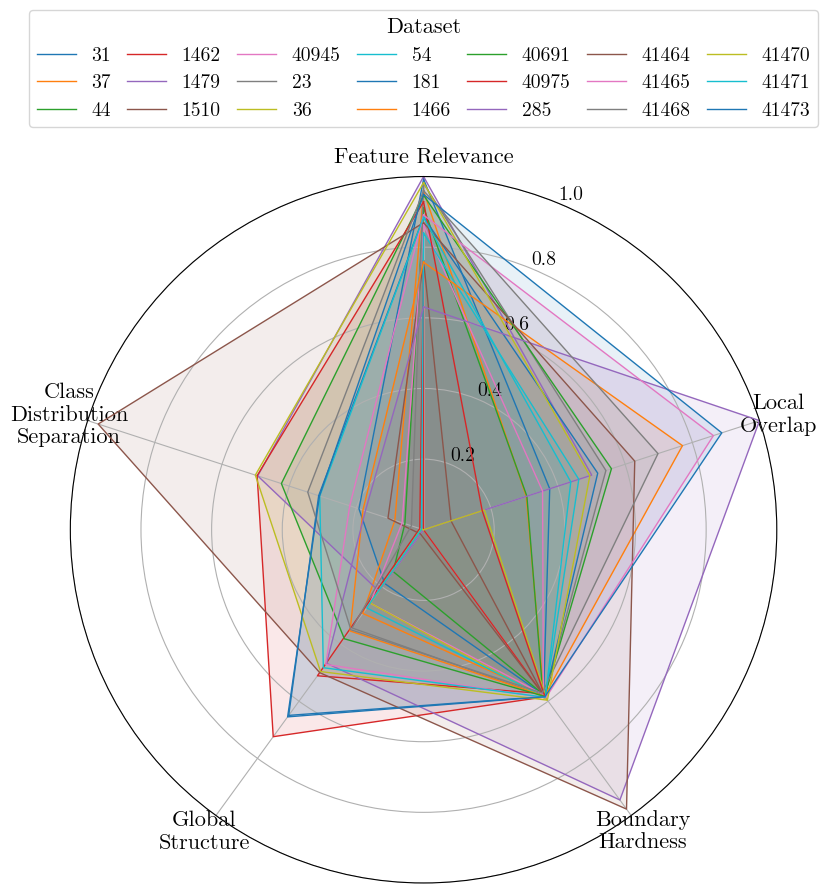

In [19]:
plot_global_radar_difficulty_subset(df_complexity_final, df_complexity_final.index.tolist(), title_suffix="(All Datasets)", filename_suffix="all")

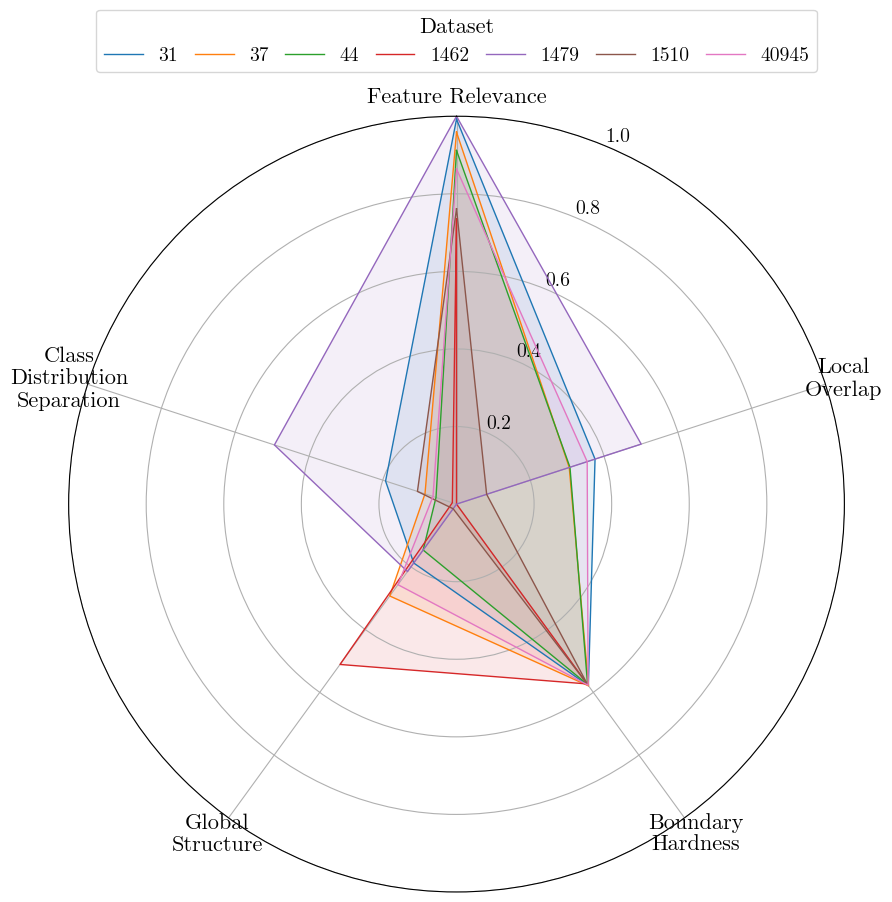

In [20]:
plot_global_radar_difficulty_subset(df_complexity_final, binary_datasets, title_suffix="(Binary Classification)", filename_suffix="binary")

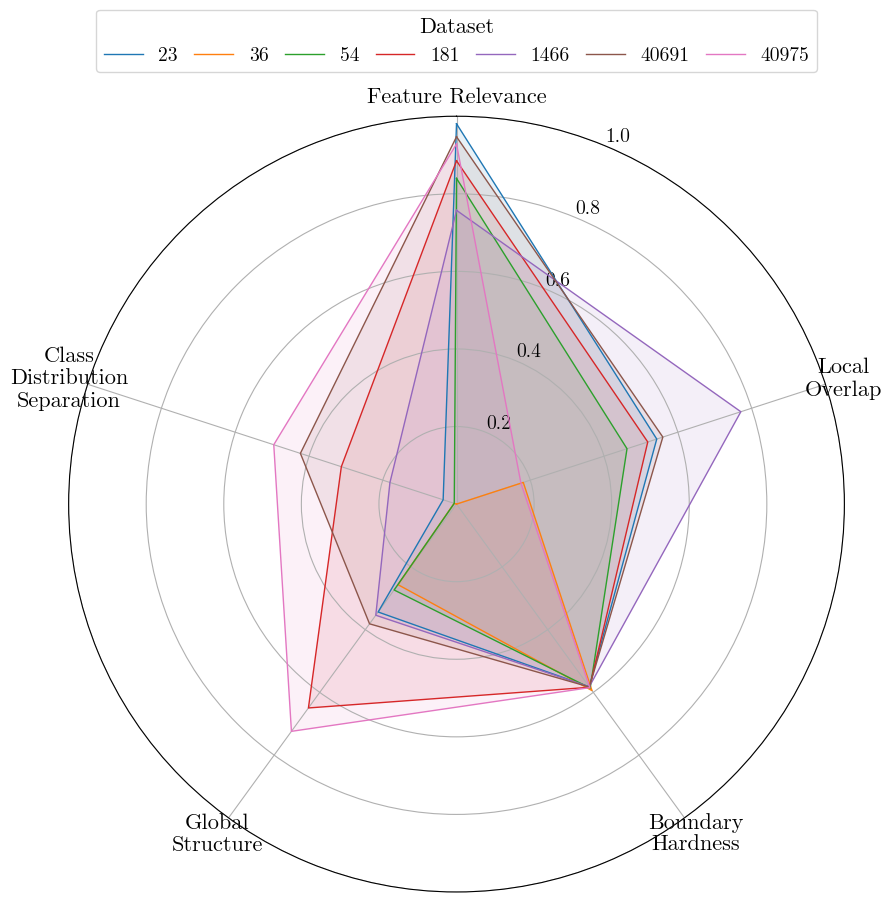

In [21]:
plot_global_radar_difficulty_subset(df_complexity_final, multiclass_datasets, title_suffix="(Multiclass Classification)", filename_suffix="multiclass")

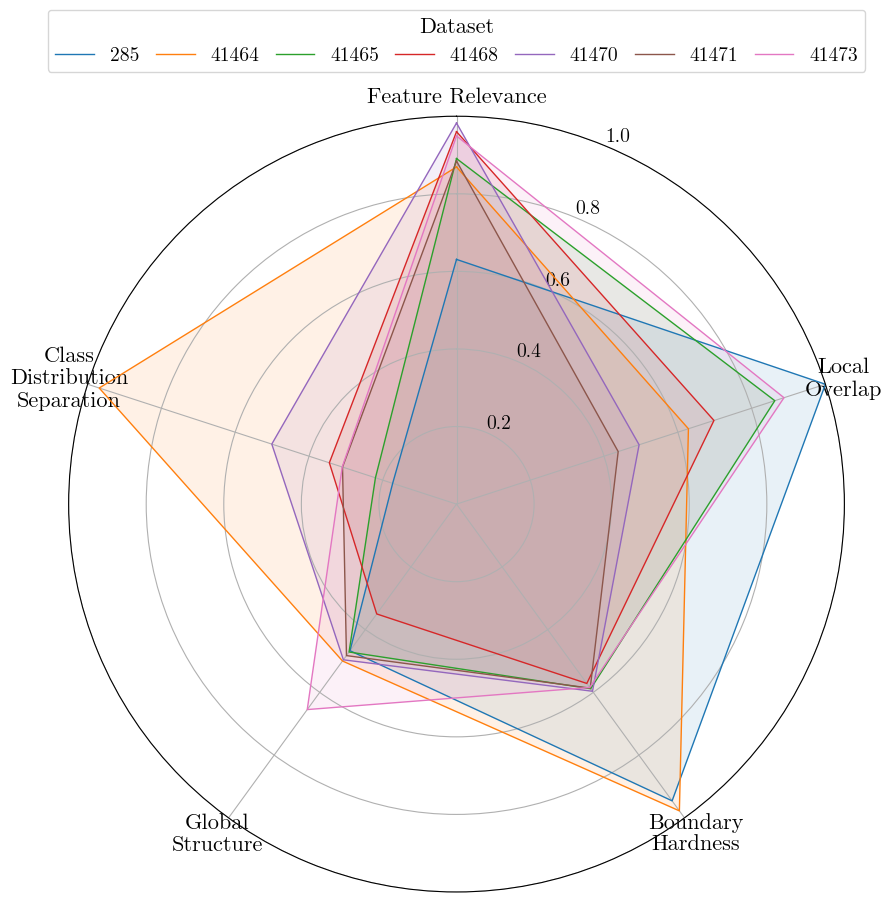

In [22]:
plot_global_radar_difficulty_subset(df_complexity_final, multilabel_datasets, title_suffix="(Multilabel Classification)", filename_suffix="multilabel")